In [1]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm
from scipy.optimize import minimize

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)

from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

In [2]:
filename = "occupancy_locus(chrII:273000-283000)"
occupancy = np.load(f"methylation_occupancy/{filename}.npy")
def extract_locus(locus_txt):
    locus_txt = locus_txt.replace(',', '')
    parts = locus_txt.split(':')
    chrom = parts[0]
    start, end = map(int, parts[1].split('-'))
    return (chrom, start, end)

locus = extract_locus(filename.lstrip("occupancy_locus(").rstrip(")"))
chrom, start, end = locus

In [3]:
chrom_number = chrom.lstrip("chr")

chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
length = end-start + 2000
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = start - 1000
locus_end = locus_start + length
#locus_sequence = chromosome[-10001 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)

Selected chromosome: .genomes/sacCer3, chrII  len=813184


In [4]:
import numpy as np
from scipy.optimize import minimize, differential_evolution

def model_func(fiber, period, amplitude, chemical_potential):
    fiber.calc_energy_landscape(
        octamer=True,
        period=period,
        amplitude=amplitude,
        chemical_potential=chemical_potential,
    )
    return fiber.occupancy[1000:-1000]

def lsq_fit(fiber, occupancy, model_func, bounds, x0=None, use_de=True,
            maxiter=1000, tol=1e-7):
    y_data = np.asarray(occupancy)

    def cost(params):
        y_pred = model_func(fiber, *params)
        return np.sum((y_pred - y_data) ** 2)

    if use_de:
        result = differential_evolution(
            cost,
            bounds=bounds,
            strategy='best1bin',
            maxiter=maxiter,
            tol=tol,
            seed=0,
            polish=True,
        )
    else:
        if x0 is None:
            x0 = [(lo + hi) / 2 for lo, hi in bounds]
        result = minimize(
            cost,
            x0=x0,
            method='L-BFGS-B',
            bounds=bounds,
            options={'ftol': tol, 'maxiter': maxiter},
        )
    return result.x


bounds = [
    (8,     12),    # period
    (0.001, 0.249), # amplitude
    (0,     20),    # chemical_potential
]


segment_length = 400
segments = (end-start) // segment_length
seg_model_len = segment_length + 2000
var_dic = {'amplitude': np.zeros(segments), 'period': np.zeros(segments), 'chemical_potential': np.zeros(segments)}

x_coords = np.arange(start, end)
distribution = []


In [5]:
for k in tqdm(range(segments)):
    seg_start = locus_start + (k * segment_length)
    seg_end = seg_start + seg_model_len
    if seg_end > locus_end:
        seg_end = locus_end
    seg_sequence = chromosome[seg_start:seg_end]
    seg_fiber = ChromatinFiber(sequence=seg_sequence, start=seg_start)
    period_lsq, amplitude_lsq, chemical_potential_lsq = lsq_fit(seg_fiber, occupancy[k*segment_length:(k+1)*segment_length], model_func, bounds, x0=None, use_de=True)
    var_dic['amplitude'][k] = amplitude_lsq
    var_dic['period'][k] = period_lsq
    var_dic['chemical_potential'][k] = chemical_potential_lsq


100%|██████████| 25/25 [08:05<00:00, 19.43s/it]


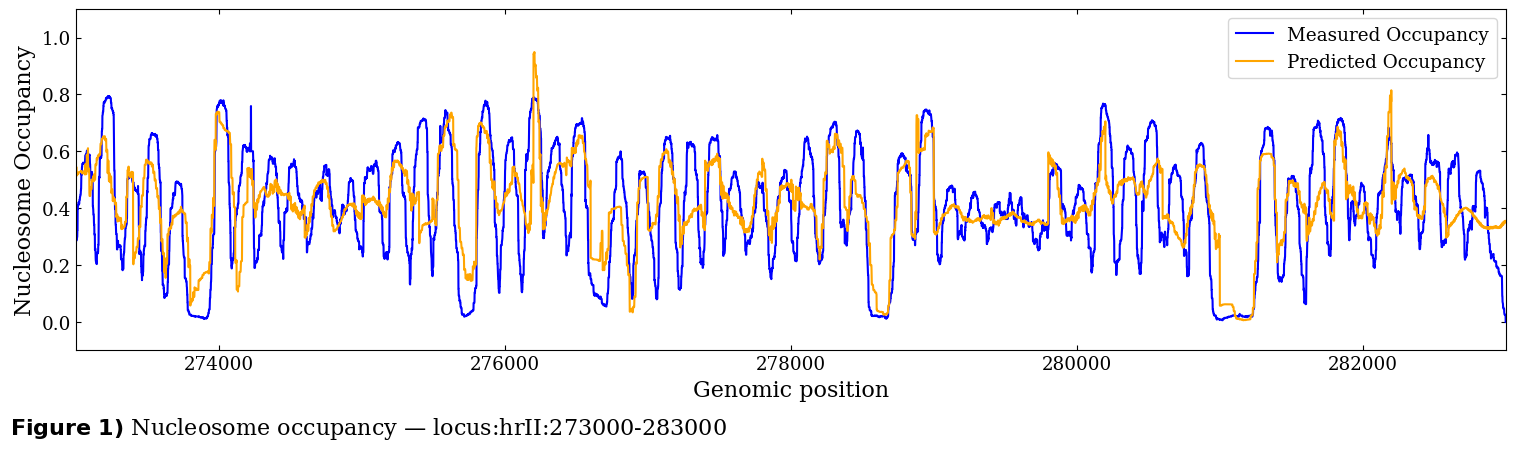

In [6]:
for k in range(segments):
    seg_start = locus_start + (k * segment_length)
    seg_end = seg_start + seg_model_len
    if seg_end > locus_end:
        seg_end = locus_end
    seg_sequence = chromosome[seg_start:seg_end]
    seg_fiber = ChromatinFiber(sequence=seg_sequence, start=seg_start)
    seg_fiber.calc_energy_landscape(
        octamer=True,
        period=var_dic['period'][k],
        amplitude=var_dic['amplitude'][k],
        chemical_potential=var_dic['chemical_potential'][k],
    )
    distribution.extend(seg_fiber.occupancy[1000:-1000])

plotter = Plotter(fig_size=(15, 4))
plotter.new(ncols=1, nrows=1)
ax = plotter.axes
ax.plot(x_coords, occupancy, color='blue', label='Measured Occupancy')
ax.plot(x_coords, distribution, color='orange', label='Predicted Occupancy')
ax.set_ylim(-0.1, 1.1)
ax.set_xlim(start, end)
ax.set_xlabel("Genomic position")
ax.set_ylabel("Nucleosome Occupancy")
ax.legend()
plotter.caption(f"Nucleosome occupancy — locus:{chrom}:{start}-{end}")

In [7]:
print(max(var_dic['period']), min(var_dic['period']))
print(max(var_dic['amplitude']), min(var_dic['amplitude']))
print(max(var_dic['chemical_potential']), min(var_dic['chemical_potential']))

11.4820393233822 8.000000010089716
0.12598501137648963 0.014506188208850985
19.999999955686288 5.257034950633841


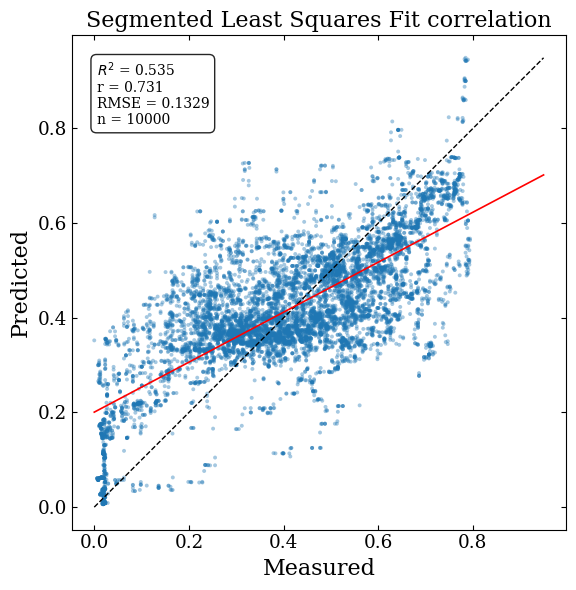

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(measured, predicted, ax=None, title=None):
    """
    Scatter plot of predicted vs measured values with R² and Pearson r.

    Parameters
    ----------
    measured : array-like
        Observed/experimental occupancy.
    predicted : array-like
        Model output (e.g. from model_func with fitted parameters).
    ax : matplotlib Axes, optional
        Existing axis to draw into. If None, a new figure is created.
    title : str, optional
    """
    measured = np.asarray(measured).ravel()
    predicted = np.asarray(predicted).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Statistics
    r, p_value = pearsonr(measured, predicted)
    r_squared = r ** 2
    rmse = np.sqrt(np.mean((predicted - measured) ** 2))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter
    ax.scatter(measured, predicted, s=8, alpha=0.4, edgecolor='none')

    # y = x reference line
    lo = min(measured.min(), predicted.min())
    hi = max(measured.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')

    # Linear fit line
    slope, intercept = np.polyfit(measured, predicted, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, 'r-', lw=1.2,
            label=f'fit: y = {slope:.2f}x + {intercept:.2f}')

    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.set_title(title or 'Segmented Least Squares Fit correlation')
    ax.set_aspect('equal', adjustable='box')

    # Annotation box with stats
    stats_text = (
        f'$R^2$ = {r_squared:.3f}\n'
        f'r = {r:.3f}\n'
        f'RMSE = {rmse:.4f}\n'
        f'n = {len(measured)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    plt.tight_layout()
    return measured, predicted, slope, intercept, r, r_squared, ax

m, p, s, i, r, r_squared, a = plot_correlation(occupancy, distribution)

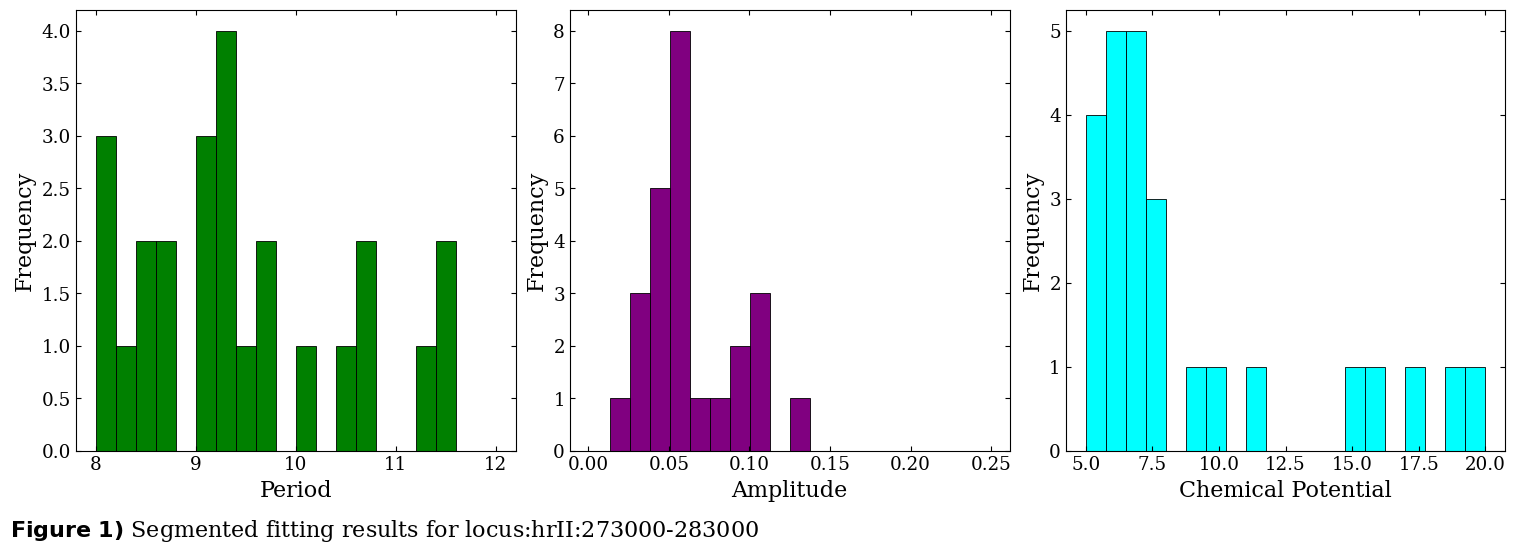

In [9]:
xs = np.linspace(0, 1, 100)
plotter = Plotter(fig_size=(15, 5))
plotter.new(ncols=3, nrows=1)
ax1, ax2, ax3 = plotter.axes
ax1.hist(var_dic['period'], bins=20, range=(8, 12),color='green', edgecolor='black', linewidth=0.6)
ax2.hist(var_dic['amplitude'], bins=20, range=(0.001, 0.249), color='purple', edgecolor='black', linewidth=0.6)
ax3.hist(var_dic['chemical_potential'], bins=20, range=(5.0, 20.0), color='cyan', edgecolor='black', linewidth=0.6)
ax1.set_xlabel("Period")
ax2.set_xlabel("Amplitude")
ax3.set_xlabel("Chemical Potential")
ax1.set_ylabel("Frequency")
ax2.set_ylabel("Frequency")
ax3.set_ylabel("Frequency")

plotter.caption(f"Segmented fitting results for locus:{chrom}:{start}-{end}")

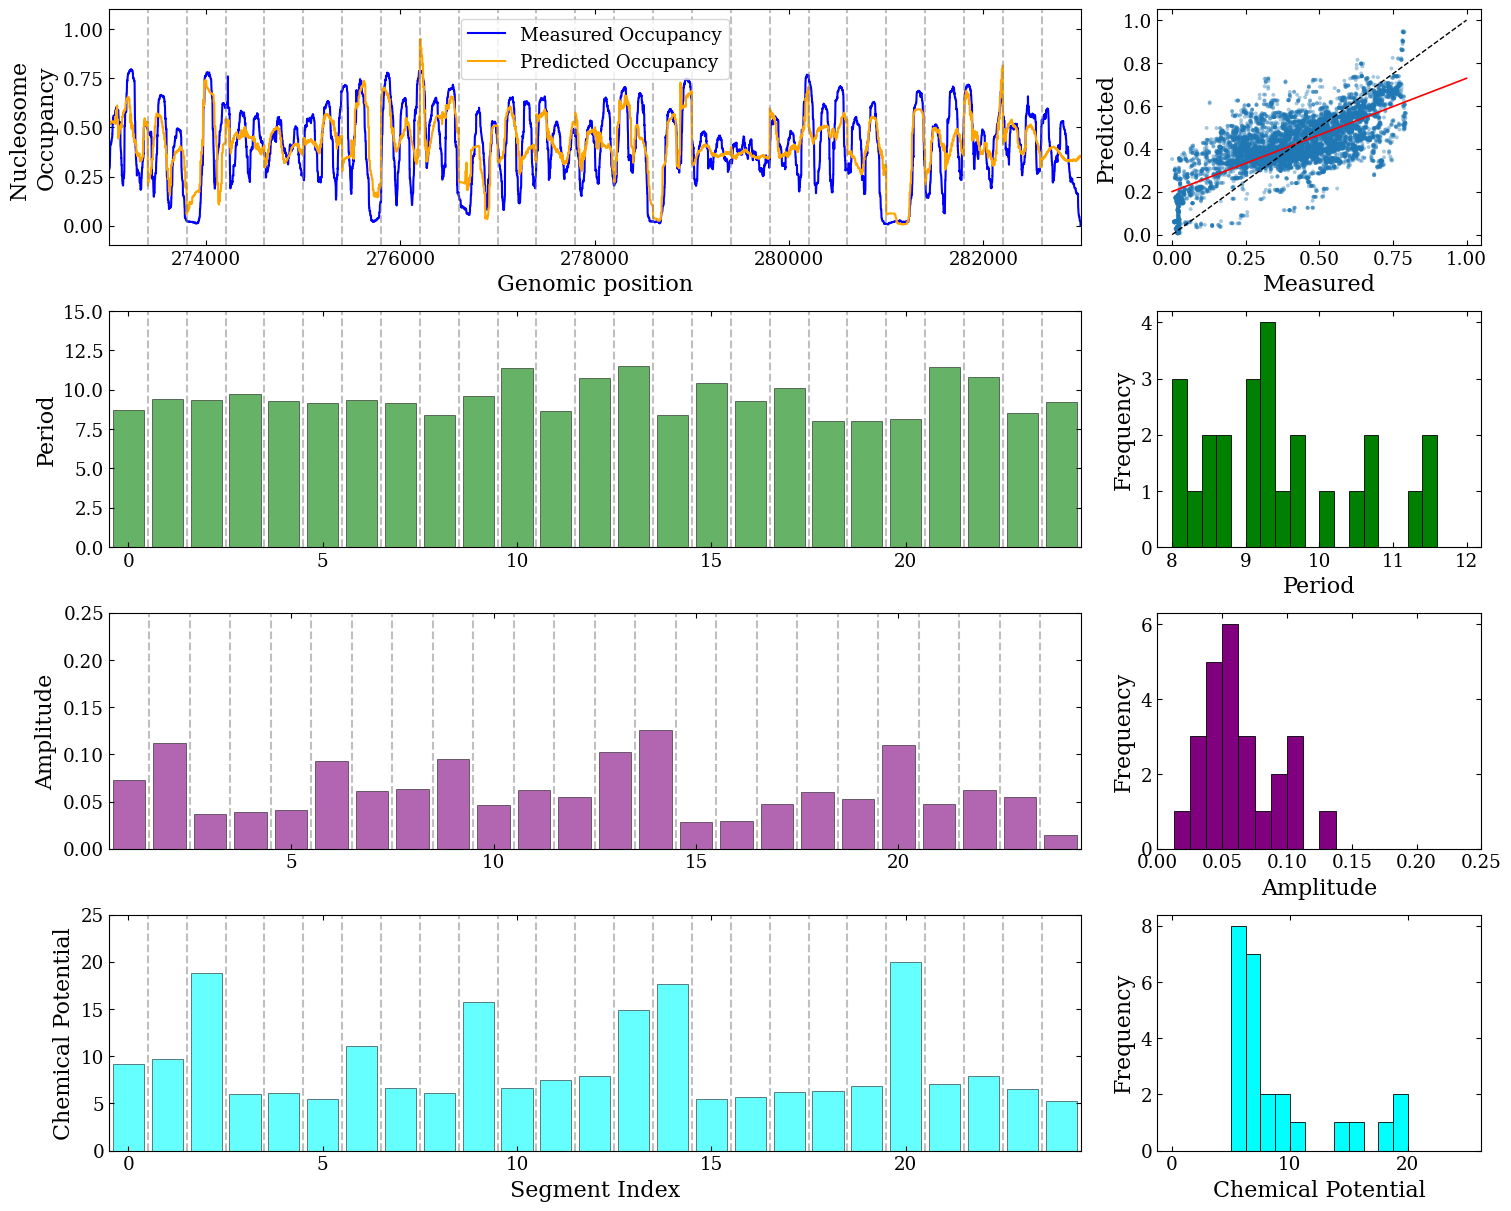

In [10]:
xs = np.linspace(0, 1, 100)

plotter = Plotter(fig_size=(15, 12))
plotter.new(ncols=2, nrows=4, width_ratios=[3, 1])
(ax1, ax1b), (ax2, ax2b), (ax3, ax3b), (ax4, ax4b) = plotter.axes
ax1.plot(x_coords, occupancy, color='blue', label='Measured Occupancy')
ax1.plot(x_coords, distribution, color='orange', label='Predicted Occupancy')
ax1.vlines(x_coords[::segment_length], ymin=-0.1, ymax=1.1, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylim(-0.1, 1.1)
ax1.set_xlim(start, end)

ax1b.scatter(m, p, s=8, alpha=0.4, edgecolor='none')
ax1b.plot(xs, s*xs + i, 'r-', lw=1.2, label=f'fit: y = {s:.2f}x + {i:.2f}')
ax1b.plot(xs, xs, 'k--', lw=1, label='y = x')
ax1b.set_xlabel("Measured")
ax1b.set_ylabel("Predicted")

ax2.bar(range(len(var_dic['period'])), var_dic['period'], edgecolor='black', linewidth=0.6, color='green', alpha=0.6, label='Period')
ax2.vlines(np.arange(0, segments)-0.5, ymin=0, ymax=15, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylim(0, 15)
ax2.set_xlim(-0.5, segments-0.5)

ax2b.hist(var_dic['period'], bins=20, range=(8, 12),color='green', edgecolor='black', linewidth=0.6)
ax2b.set_xlabel("Period")
ax2b.set_ylabel("Frequency")

ax3.bar(range(len(var_dic['amplitude'])), var_dic['amplitude'], edgecolor='black', linewidth=0.6, color='purple', alpha=0.6, label='Amplitude')
ax3.vlines(np.arange(0, segments)-0.5, ymin=0, ymax=1, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylim(0, 0.25)
ax3.set_xlim(0.5, segments-0.5)

ax3b.hist(var_dic['amplitude'], bins=20, range=(0, 0.25),color='purple', edgecolor='black', linewidth=0.6)
ax3b.set_xlabel("Amplitude")
ax3b.set_ylabel("Frequency")
ax3b.set_xlim(0.0, 0.25)
ax3b.set_xticks(np.arange(0, 0.3, 0.05))

ax4.bar(range(len(var_dic['chemical_potential'])), var_dic['chemical_potential'], edgecolor='black', linewidth=0.6, color='cyan', alpha=0.6, label='Chemical Potential')
ax4.vlines(np.arange(0, segments)-0.5, ymin=0, ymax=25, color='gray', linestyle='--', alpha=0.5)
ax4.set_ylim(0, 25)
ax4.set_xlim(-0.5, segments-0.5)
ax4.set_xlabel("Segment Index")

ax4b.hist(var_dic['chemical_potential'], bins=20, range=(0, 25),color='cyan', edgecolor='black', linewidth=0.6)
ax4b.set_xlabel("Chemical Potential")
ax4b.set_ylabel("Frequency")

ax1.set_xlabel("Genomic position")
ax1.set_ylabel("Nucleosome \nOccupancy")
ax2.set_ylabel("Period")
ax3.set_ylabel("Amplitude")
ax4.set_ylabel("Chemical Potential")
ax1.legend()

In [11]:
import json

# ── Full-chromosome segmented fitting ──────────────────────────────────────
# Change chrom_name to process a different chromosome.
# Results saved to segmented_fitting_params/{chrom_name}_params.npz
# Press stop (■) at any time — re-running resumes from the last completed segment.

chrom_name     = "chrII"
segment_length = 400
padding        = 1000
genome_fasta   = r".genomes/sacCer3/sacCer3.fa"

bounds = [
    (8,     12),
    (0.001, 0.249),
    (0,     20),
]

out_dir   = Path("segmented_fitting_params")
out_dir.mkdir(exist_ok=True)
out_path  = out_dir / f"{chrom_name}_filtered_params.npz"
ckpt_path = out_dir / f"{chrom_name}_filtered_checkpoint.json"

# --- Load occupancy ---
occ_path        = Path(f"full_methylation_data_10000bp_interval_meth_filtered/{chrom_name}/occupancy_{chrom_name}.npy")
occupancy_chrom = np.load(occ_path)
chrom_len       = len(occupancy_chrom)
segments        = chrom_len // segment_length
print(f"{chrom_name}: {chrom_len:,} bp → {segments} segments of {segment_length} bp")

# --- Load genome sequence ---
chrom_number = chrom_name.lstrip("chr")
chromosome   = fetch_chromosome_sequence(genome_fasta, chromosome=chrom_number)

# --- Resume or start fresh ---
if out_path.exists() and ckpt_path.exists():
    data      = np.load(out_path)
    periods   = data['period'].copy()
    amplitudes = data['amplitude'].copy()
    chems     = data['chemical_potential'].copy()
    completed = set(json.loads(ckpt_path.read_text()))
    print(f"  Resuming: {len(completed)}/{segments} segments already done")
else:
    periods    = np.zeros(segments)
    amplitudes = np.zeros(segments)
    chems      = np.zeros(segments)
    completed  = set()

# --- Fit each segment ---
for k in tqdm(range(segments), desc=f"Fitting {chrom_name}"):
    if k in completed:
        continue

    seg_start = k * segment_length
    seg_end   = min(seg_start + segment_length, chrom_len)
    seq_start = max(0, seg_start - padding)
    seq_end   = min(chrom_len, seg_end + padding)
    pad_lo    = seg_start - seq_start

    seg_fiber = ChromatinFiber(sequence=chromosome[seq_start:seq_end], start=seq_start)

    def model_func_seg(fiber, period, amplitude, chemical_potential):
        fiber.calc_energy_landscape(
            octamer=True, period=period,
            amplitude=amplitude, chemical_potential=chemical_potential,
        )
        return fiber.occupancy[pad_lo : pad_lo + (seg_end - seg_start)]

    period_lsq, amplitude_lsq, chem_lsq = lsq_fit(
        seg_fiber,
        occupancy_chrom[seg_start:seg_end],
        model_func_seg,
        bounds,
        x0=None, use_de=True, maxiter=750, tol=1e-5,
    )
    periods[k]    = period_lsq
    amplitudes[k] = amplitude_lsq
    chems[k]      = chem_lsq

    completed.add(k)
    np.savez(out_path, period=periods, amplitude=amplitudes,
             chemical_potential=chems,
             segment_length=np.array(segment_length),
             chrom_len=np.array(chrom_len))
    ckpt_path.write_text(json.dumps(list(completed)))

# ckpt_path.unlink(missing_ok=True)
print(f"Saved → {out_path}  ({segments} segments)")

chrII: 813,184 bp → 2032 segments of 400 bp
Selected chromosome: .genomes/sacCer3, chrII  len=813184
  Resuming: 1871/2032 segments already done


Fitting chrII: 100%|██████████| 2032/2032 [29:40<00:00,  1.14it/s] 

Saved → segmented_fitting_params/chrII_filtered_params.npz  (2032 segments)


Period: 9.84 bp (range: 8.00 - 12.00)
Median Period: 9.76 bp
Amplitude: 0.0516 (range: 0.0010 - 0.2180)
Median Amplitude: 0.0452
Chemical potential: 7.83 kT (range: 4.11 - 20.00)
Median Chemical potential: 6.52 kT


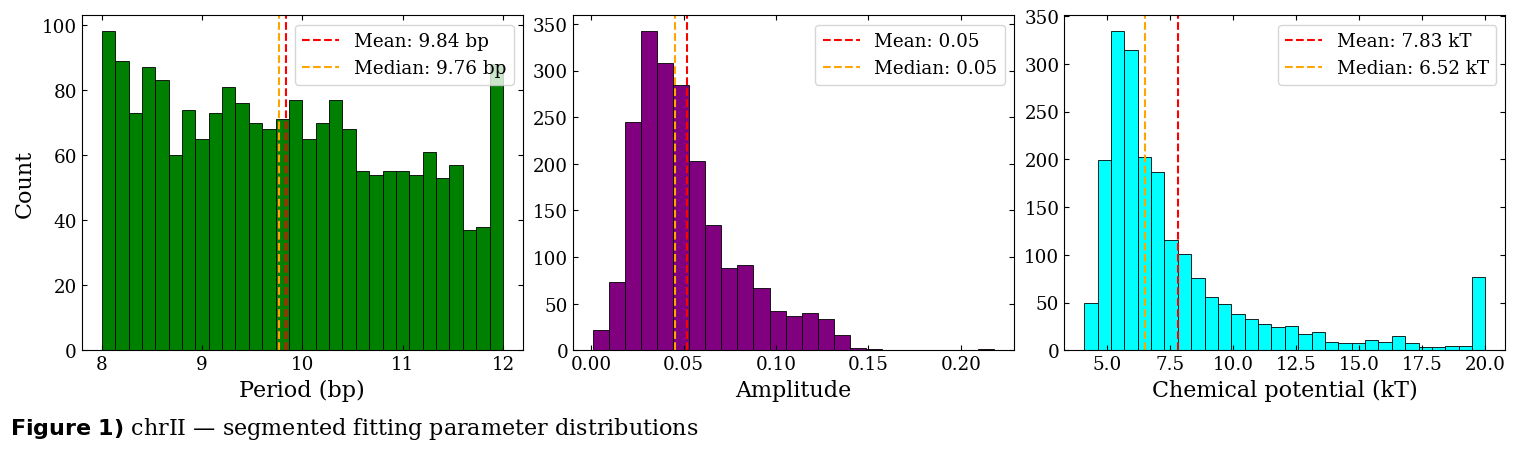

In [12]:
# Load params (works whether fitting is complete or still in progress)
chrom_name = "chrII"

out_dir   = Path("segmented_fitting_params")
out_dir.mkdir(exist_ok=True)
out_path  = out_dir / f"{chrom_name}_filtered_params.npz"

data = np.load(out_path)
periods    = data['period']
amplitudes = data['amplitude']
chems      = data['chemical_potential']

mean_period = np.mean(periods) 
mean_amplitude = np.mean(amplitudes) 
mean_chem = np.mean(chems) 

median_period = np.median(periods) 
median_amplitude = np.median(amplitudes) 
median_chem = np.median(chems) 

print(f"Period: {mean_period:.2f} bp (range: {periods.min():.2f} - {periods.max():.2f})")
print(f"Median Period: {median_period:.2f} bp")
print(f"Amplitude: {mean_amplitude:.4f} (range: {amplitudes.min():.4f} - {amplitudes.max():.4f})")
print(f"Median Amplitude: {median_amplitude:.4f}")
print(f"Chemical potential: {mean_chem:.2f} kT (range: {chems.min():.2f} - {chems.max():.2f})")
print(f"Median Chemical potential: {median_chem:.2f} kT")

# Only plot fitted segments (skip zeros from unfinished runs)
# done = np.array(list(completed)) if ckpt_path.exists() else np.arange(len(periods))

plotter = Plotter(fig_size=(15, 4))
plotter.new(ncols=3, nrows=1)
ax1, ax2, ax3 = plotter.axes

ax1.hist(periods,    bins=30, color='green',  edgecolor='black', linewidth=0.6)
ax1.axvline(mean_period, color='red', linestyle='--', label=f'Mean: {mean_period:.2f} bp')
ax1.axvline(median_period, color='orange', linestyle='--', label=f'Median: {median_period:.2f} bp')
ax2.hist(amplitudes, bins=25, color='purple', edgecolor='black', linewidth=0.6)
ax2.axvline(mean_amplitude, color='red', linestyle='--', label=f'Mean: {mean_amplitude:.2f}')
ax2.axvline(median_amplitude, color='orange', linestyle='--', label=f'Median: {median_amplitude:.2f}')
ax3.hist(chems,      bins=30, color='cyan',   edgecolor='black', linewidth=0.6)
ax3.axvline(mean_chem, color='red', linestyle='--', label=f'Mean: {mean_chem:.2f} kT')
ax3.axvline(median_chem, color='orange', linestyle='--', label=f'Median: {median_chem:.2f} kT')

ax1.set_xlabel("Period (bp)")
ax2.set_xlabel("Amplitude")
ax3.set_xlabel("Chemical potential (kT)")
ax1.set_ylabel("Count")
ax1.legend()
ax2.legend()
ax3.legend()

plotter.caption(f"{chrom_name} — segmented fitting parameter distributions ")


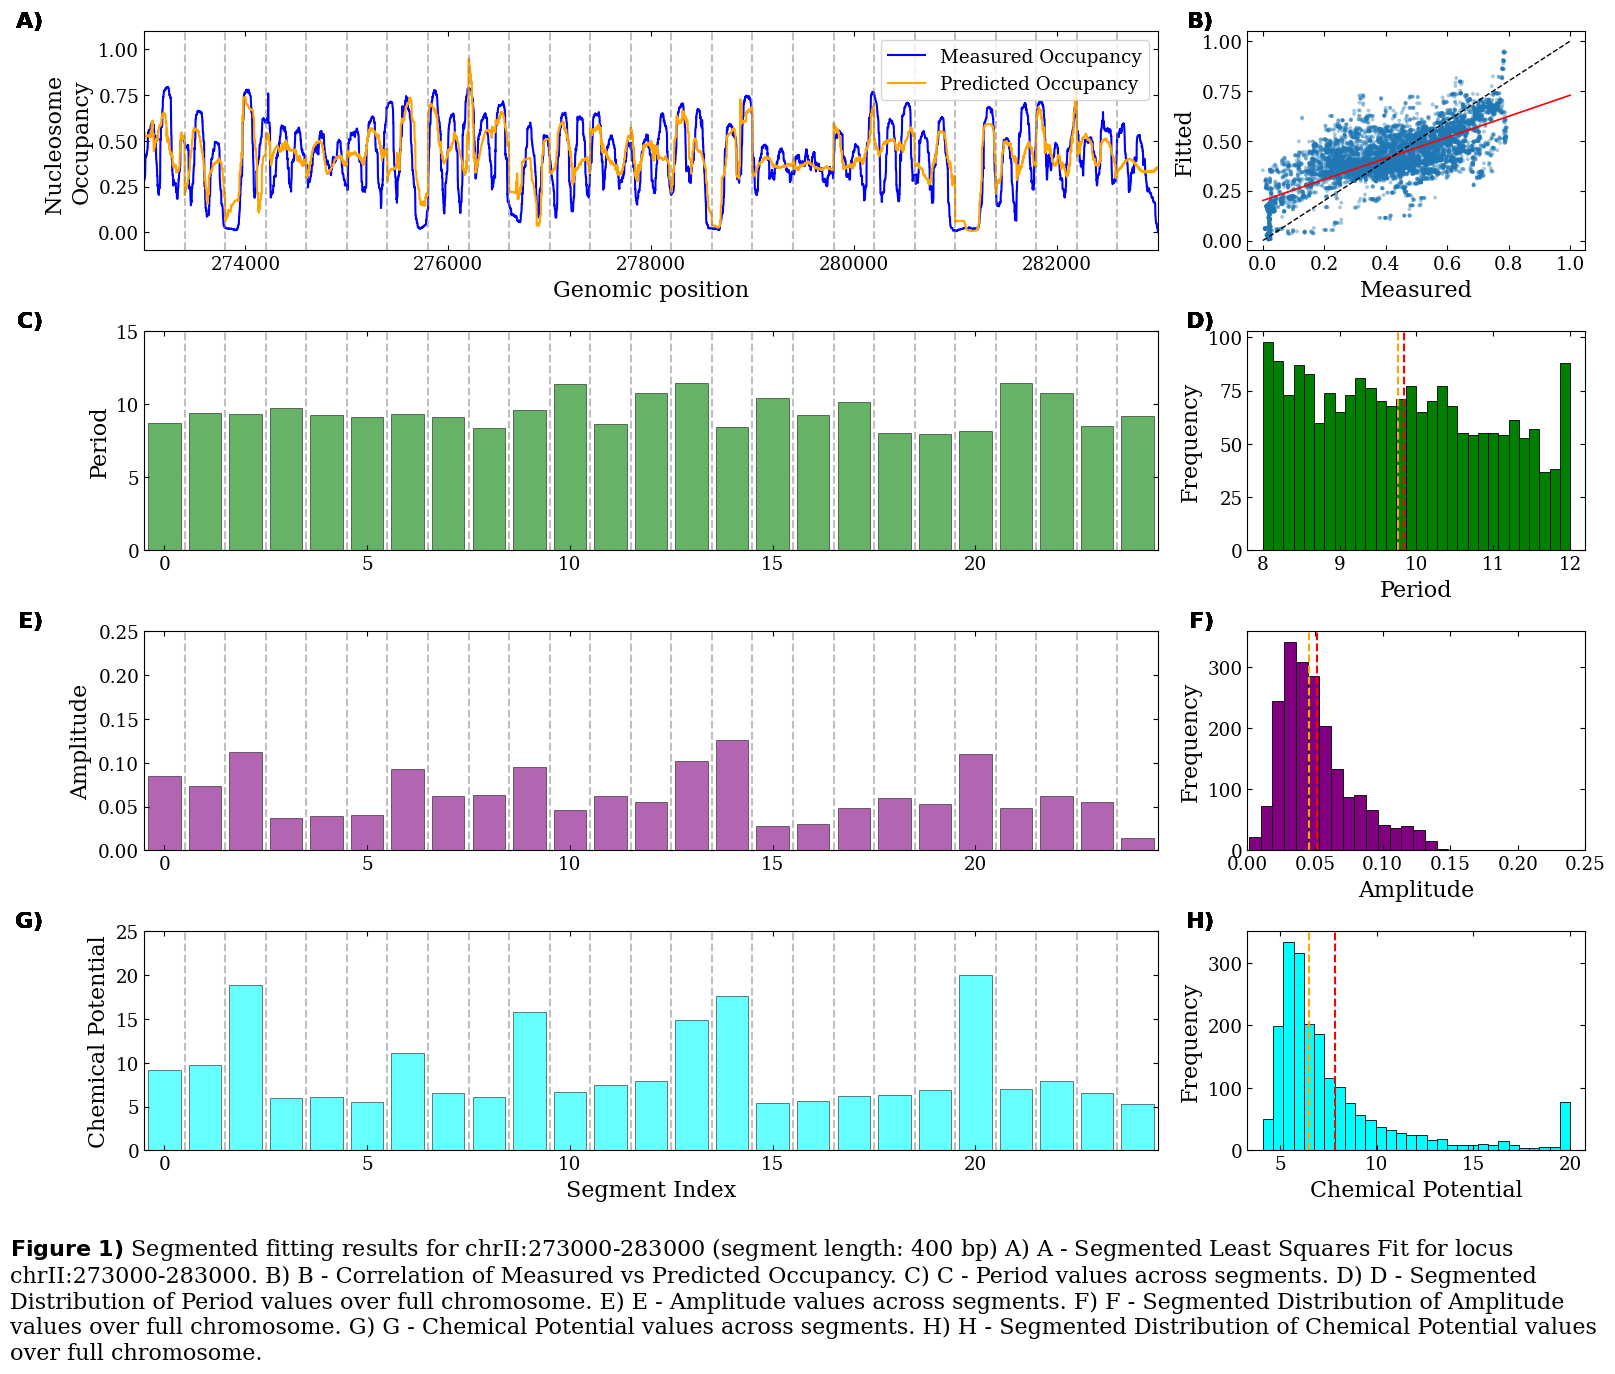

In [13]:
xs = np.linspace(0, 1, 100)

plotter = Plotter(fig_size=(16, 12))
plotter.new(ncols=2, nrows=4, width_ratios=[3, 1])
(ax1, ax1b), (ax2, ax2b), (ax3, ax3b), (ax4, ax4b) = plotter.axes
ax1.plot(x_coords, occupancy, color='blue', label='Measured Occupancy')
ax1.plot(x_coords, distribution, color='orange', label='Predicted Occupancy')
ax1.vlines(x_coords[::segment_length], ymin=-0.1, ymax=1.1, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylim(-0.1, 1.1)
ax1.set_xlim(start, end)

ax1b.scatter(m, p, s=8, alpha=0.4, edgecolor='none')
ax1b.plot(xs, s*xs + i, 'r-', lw=1.2, label=f'fit: y = {s:.2f}x + {i:.2f}')
ax1b.plot(xs, xs, 'k--', lw=1, label='y = x')
ax1b.set_xlabel("Measured")
ax1b.set_ylabel("Fitted")

ax2.bar(range(len(var_dic['period'])), var_dic['period'], edgecolor='black', linewidth=0.6, color='green', alpha=0.6, label='Period')
ax2.vlines(np.arange(0, 25)-0.5, ymin=0, ymax=15, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylim(0, 15)
ax2.set_xlim(-0.5, 25-0.5)

ax2b.hist(periods,    bins=30, color='green',  edgecolor='black', linewidth=0.6)
ax2b.axvline(mean_period, color='red', linestyle='--', label=f'Mean: {mean_period:.2f} bp')
ax2b.axvline(median_period, color='orange', linestyle='--', label=f'Median: {median_period:.2f} bp')
ax2b.set_xlabel("Period")
ax2b.set_ylabel("Frequency")

ax3.bar(range(len(var_dic['amplitude'])), var_dic['amplitude'], edgecolor='black', linewidth=0.6, color='purple', alpha=0.6, label='Amplitude')
ax3.vlines(np.arange(0, 25)-0.5, ymin=0, ymax=1, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylim(0, 0.25)
ax3.set_xlim(-0.5, 25-0.5)

ax3b.hist(amplitudes, bins=25, color='purple', edgecolor='black', linewidth=0.6)
ax3b.axvline(mean_amplitude, color='red', linestyle='--', label=f'Mean: {mean_amplitude:.2f}')
ax3b.axvline(median_amplitude, color='orange', linestyle='--', label=f'Median: {median_amplitude:.2f}')
ax3b.set_xlabel("Amplitude")
ax3b.set_ylabel("Frequency")
ax3b.set_xlim(0.0, 0.25)
ax3b.set_xticks(np.arange(0, 0.3, 0.05))

ax4.bar(range(len(var_dic['chemical_potential'])), var_dic['chemical_potential'], edgecolor='black', linewidth=0.6, color='cyan', alpha=0.6, label='Chemical Potential')
ax4.vlines(np.arange(0, 25)-0.5, ymin=0, ymax=25, color='gray', linestyle='--', alpha=0.5)
ax4.set_ylim(0, 25)
ax4.set_xlim(-0.5, 25-0.5)
ax4.set_xlabel("Segment Index")

ax4b.hist(chems,      bins=30, color='cyan',   edgecolor='black', linewidth=0.6)
ax4b.axvline(mean_chem, color='red', linestyle='--', label=f'Mean: {mean_chem:.2f} kT')
ax4b.axvline(median_chem, color='orange', linestyle='--', label=f'Median: {median_chem:.2f} kT')
ax4b.set_xlabel("Chemical Potential")
ax4b.set_ylabel("Frequency")

ax1.set_xlabel("Genomic position")
ax1.set_ylabel("Nucleosome \nOccupancy")
ax2.set_ylabel("Period")
ax3.set_ylabel("Amplitude")
ax4.set_ylabel("Chemical Potential")

ax1.set_title("A - Segmented Least Squares Fit for locus " + chrom_name + ":" + str(start) + "-" + str(end))
ax1b.set_title("B - Correlation of Measured vs Predicted Occupancy")
ax2.set_title("C - Period values across segments")
ax2b.set_title("D - Segmented Distribution of Period values over full chromosome")
ax3.set_title("E - Amplitude values across segments")
ax3b.set_title("F - Segmented Distribution of Amplitude values over full chromosome")
ax4.set_title("G - Chemical Potential values across segments")
ax4b.set_title("H - Segmented Distribution of Chemical Potential values over full chromosome")
ax1.legend()

plotter.caption(f"Segmented fitting results for {chrom_name}:{start}-{end} (segment length: {segment_length} bp)")

## Methylation efficiency estimation

For each of the 25 × 400 bp segments the fitted `period`, `amplitude`, and `chemical_potential` from `var_dic` are used to build a segment-specific energy landscape (mirroring cell `9000481f`). `N_configs` fiber configurations are sampled per segment and the per-position accessibility is averaged.

**Model:** `P(methylated at pos) = (1 − protected[pos]) × A/T_target[pos] × ε`

- **Approach 1 (analytical):** solve `ε = Σ(acc · exp) / Σ(acc²)` — exact least-squares for this linear model.
- **Approach 2 (differential evolution):** same accessibility, DE minimises MSE over `ε ∈ [0, 1]` numerically.

In [22]:
# --- Experimental per-position A/T methylation from pre-computed Read_bam array ---
# This matches Read_bam's get_methylation_distribution (f_meth_fwd + f_meth_rev per position).
chrom_full = "chr" + chrom_number

meth_full = np.load(f"full_methylation_data_10000bp_interval/{chrom_full}/methylation_{chrom_full}.npy")
exp_frac  = meth_full[start:end]   # shape (10000,)

print(f"Experimental mean methylation (Read_bam): {exp_frac[exp_frac > 0].mean():.4%}")
print(f"Positions with signal                    : {int((exp_frac > 0).sum()):,} / {len(exp_frac):,}")

# --- Summary parameters from segmented fitting ---
sum_period    = 10.0
sum_amplitude = float(np.median(var_dic['amplitude']))
sum_chem      = float(np.median(var_dic['chemical_potential']))
print(f"\nSummary parameters: period={sum_period}, amplitude={sum_amplitude:.4f}, chem_pot={sum_chem:.3f} kT")

# --- Compute per-position accessibility (efficiency=1) via Monte Carlo ---
N_configs = 500

fiber.calc_energy_landscape(
    octamer=True,
    period=sum_period,
    amplitude=sum_amplitude,
    chemical_potential=sum_chem,
)

acc_sum = np.zeros(end - start, dtype=np.float64)

for _ in tqdm(range(N_configs), desc="Sampling configurations"):
    dyads  = fiber.sample_fiber_configuration()
    result = fiber.calc_methylation(dyads, motifs=['A'], strand='both', efficiency=1.0)
    at_tgt = (~np.isnan(result.methylated)).astype(float)
    acc_sum += ((1.0 - result.protected) * at_tgt)[1000:-1000]

accessibility = acc_sum / N_configs
print(f"\nMean accessibility (efficiency=1): {accessibility.mean():.4f}")

Experimental mean methylation (Read_bam): 14.8700%
Positions with signal                    : 5,594 / 10,000

Summary parameters: period=10.0, amplitude=0.0602, chem_pot=6.852 kT


Sampling configurations: 100%|██████████| 500/500 [00:03<00:00, 131.08it/s]


Mean accessibility (efficiency=1): 0.2882


Analytical ε  — mean: 0.0031  std: 0.0297
DE         ε  — mean: 0.0031  std: 0.0297


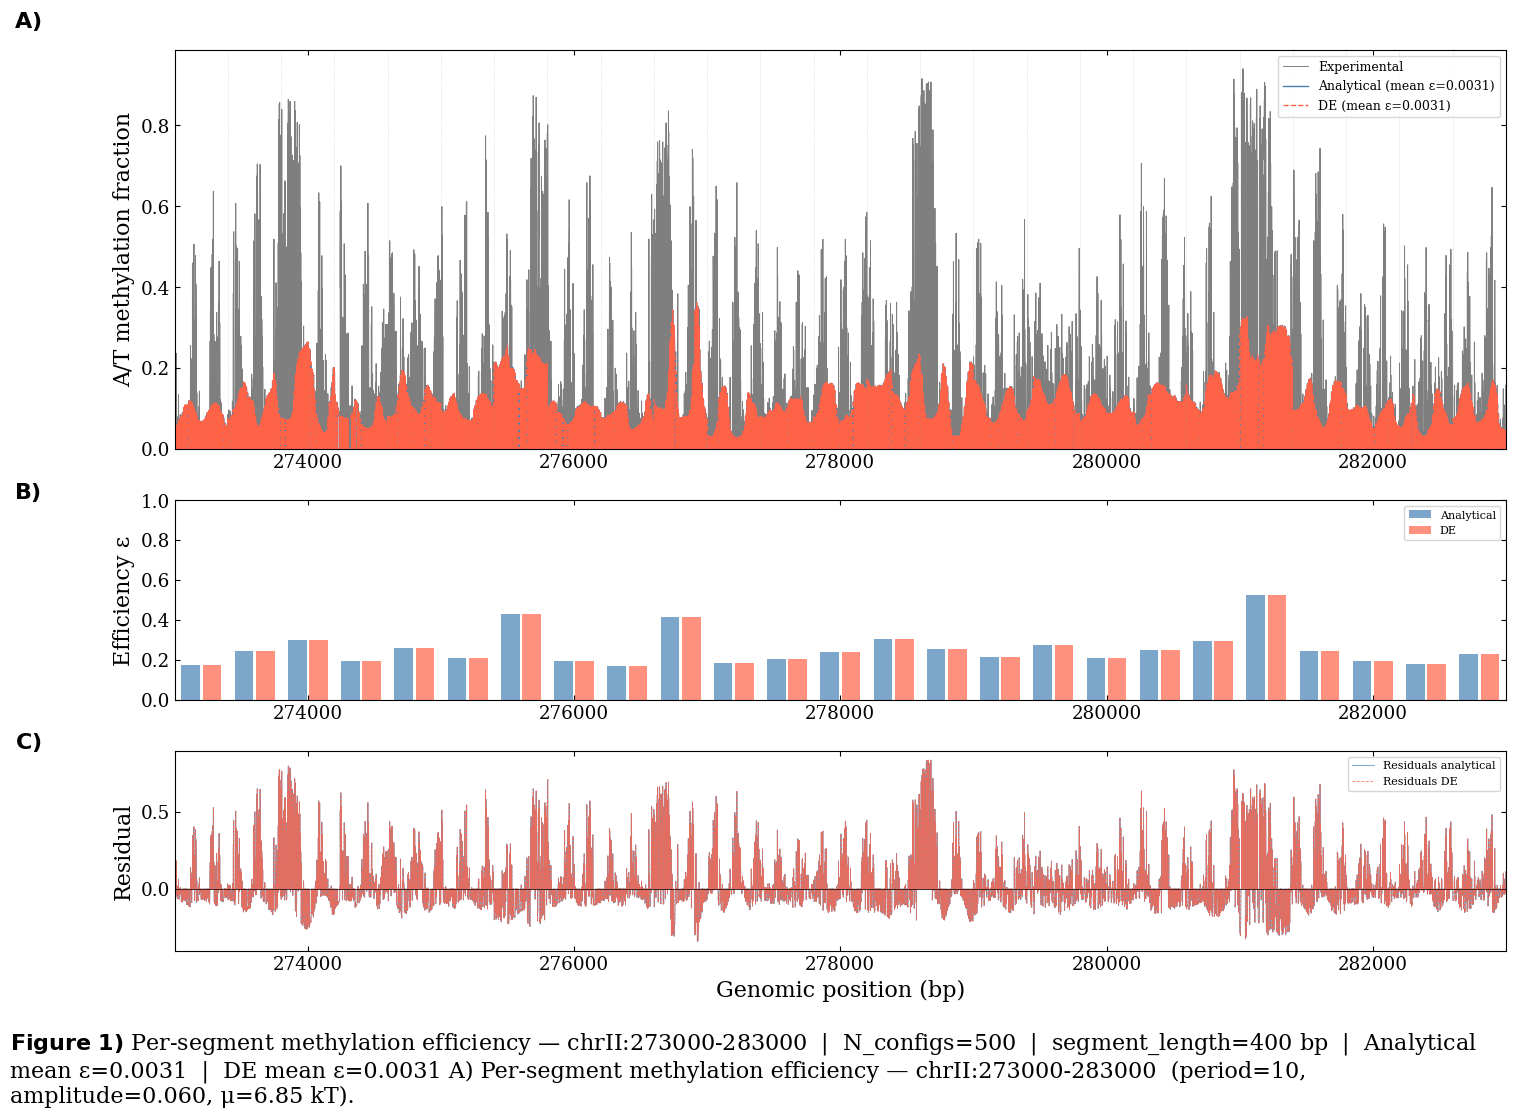

In [23]:
from scipy.optimize import differential_evolution

eff_analytical = np.zeros(segments)
eff_de         = np.zeros(segments)

for k in range(segments):
    lo = k * segment_length
    hi = lo + segment_length

    acc_k = accessibility[lo:hi]
    exp_k = exp_frac[lo:hi]

    valid = (~np.isnan(exp_k)) & (acc_k > 0)
    if valid.sum() == 0:
        continue

    av, ev = acc_k[valid], exp_k[valid]

    # Approach 1: analytical least-squares
    eff_analytical[k] = float(np.dot(av, ev) / np.dot(av, av))

    # Approach 2: differential evolution
    res = differential_evolution(
        lambda p: float(np.mean((av * p[0] - ev) ** 2)),
        bounds=[(0.0, 1.0)], seed=42, maxiter=500, tol=1e-9, polish=True,
    )
    eff_de[k] = float(res.x[0])

print(f"Analytical ε  — mean: {eff_analytical.mean():.4f}  std: {eff_analytical.std():.4f}")
print(f"DE         ε  — mean: {eff_de.mean():.4f}  std: {eff_de.std():.4f}")

# --- Build per-position predicted methylation ---
pred_analytical = np.concatenate([
    accessibility[k*segment_length:(k+1)*segment_length] * eff_analytical[k]
    for k in range(segments)
])
pred_de = np.concatenate([
    accessibility[k*segment_length:(k+1)*segment_length] * eff_de[k]
    for k in range(segments)
])

# --- Plot ---
x     = np.arange(start, end)
seg_x = np.array([start + k * segment_length + segment_length / 2 for k in range(segments)])

plotter = Plotter(fig_size=(15, 10))
plotter.new(nrows=3, sharex=False, height_ratios=[2, 1, 1])
ax_meth, ax_eff, ax_res = plotter.axes

# Top: methylation traces
ax_meth.plot(x, exp_frac, color='black', lw=0.7, alpha=0.5, label='Experimental')
ax_meth.plot(x, pred_analytical, color='steelblue', lw=1.0,
             label=f'Analytical (mean ε={eff_analytical.mean():.4f})')
ax_meth.plot(x, pred_de, color='tomato', lw=1.0, ls='--',
             label=f'DE (mean ε={eff_de.mean():.4f})')
for k in range(segments + 1):
    ax_meth.axvline(start + k * segment_length, color='gray', lw=0.4, ls=':', alpha=0.5)
ax_meth.set_ylabel('A/T methylation fraction')
ax_meth.set_ylim(0, None)
ax_meth.set_xlim(start, end)
ax_meth.legend(fontsize=9)
ax_meth.set_title(f'Per-segment methylation efficiency — {chrom_full}:{start}-{end}  '
                  f'(period=10, amplitude={sum_amplitude:.3f}, μ={sum_chem:.2f} kT)')

# Middle: per-segment ε bar chart
ax_eff.bar(seg_x - segment_length * 0.2, eff_analytical, width=segment_length * 0.35,
           color='steelblue', alpha=0.7, label='Analytical')
ax_eff.bar(seg_x + segment_length * 0.2, eff_de, width=segment_length * 0.35,
           color='tomato', alpha=0.7, label='DE')
ax_eff.set_ylabel('Efficiency ε')
ax_eff.set_xlim(start, end)
ax_eff.set_ylim(0, 1)
ax_eff.legend(fontsize=8)

# Bottom: residuals
ax_res.plot(x, exp_frac - pred_analytical, color='steelblue', lw=0.6, alpha=0.8, label='Residuals analytical')
ax_res.plot(x, exp_frac - pred_de, color='tomato', lw=0.6, alpha=0.8, ls='--', label='Residuals DE')
ax_res.axhline(0, color='k', lw=0.5)
ax_res.set_ylabel('Residual')
ax_res.set_xlabel('Genomic position (bp)')
ax_res.set_xlim(start, end)
ax_res.legend(fontsize=8)

plotter.caption(
    f"Per-segment methylation efficiency — {chrom_full}:{start}-{end}  |  "
    f"N_configs={N_configs}  |  segment_length={segment_length} bp  |  "
    f"Analytical mean ε={eff_analytical.mean():.4f}  |  DE mean ε={eff_de.mean():.4f}"
)

Segments:   0%|          | 0/25 [00:00<?, ?it/s]/tmp/ipykernel_2371/4281412008.py:33: RuntimeWarning: Mean of empty slice
  mean_base = np.nanmean(base_stack, axis=0)   # (inner_len,)
Segments: 100%|██████████| 25/25 [00:01<00:00, 18.28it/s]


DE ε — mean: 0.2530   std: 0.0682
  segment  0 (273000–273400): ε = 0.2312
  segment  1 (273400–273800): ε = 0.2964
  segment  2 (273800–274200): ε = 0.3526
  segment  3 (274200–274600): ε = 0.1907
  segment  4 (274600–275000): ε = 0.2420
  segment  5 (275000–275400): ε = 0.2019
  segment  6 (275400–275800): ε = 0.3625
  segment  7 (275800–276200): ε = 0.2305
  segment  8 (276200–276600): ε = 0.2337
  segment  9 (276600–277000): ε = 0.2816
  segment 10 (277000–277400): ε = 0.2519
  segment 11 (277400–277800): ε = 0.1680
  segment 12 (277800–278200): ε = 0.2515
  segment 13 (278200–278600): ε = 0.2793
  segment 14 (278600–279000): ε = 0.4314
  segment 15 (279000–279400): ε = 0.1857
  segment 16 (279400–279800): ε = 0.2359
  segment 17 (279800–280200): ε = 0.2035
  segment 18 (280200–280600): ε = 0.2651
  segment 19 (280600–281000): ε = 0.2384
  segment 20 (281000–281400): ε = 0.3913
  segment 21 (281400–281800): ε = 0.2564
  segment 22 (281800–282200): ε = 0.1816
  segment 23 (282200–28

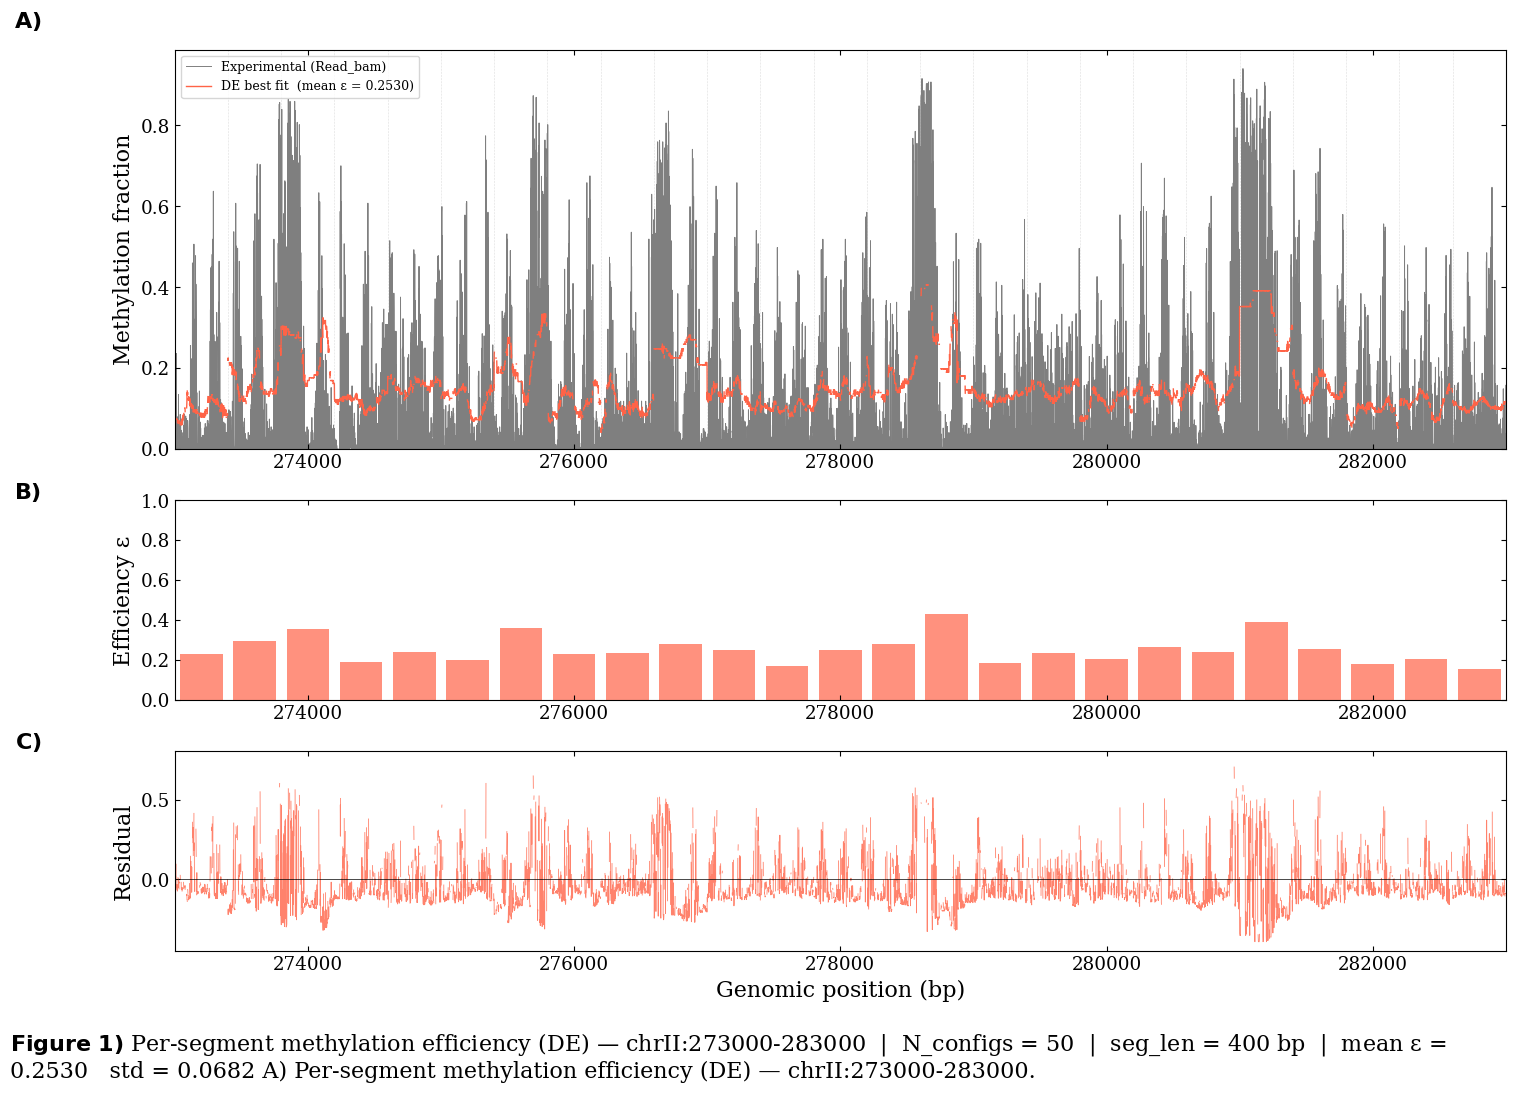

In [24]:
from scipy.optimize import differential_evolution

N_configs    = 50
n_seg        = len(var_dic['amplitude'])   # 25 locus segments
seg_len      = (end - start) // n_seg      # 400 bp

eff_de    = np.zeros(n_seg)
pred_best = np.full(end - start, np.nan)

for k in tqdm(range(n_seg), desc="Segments"):
    seg_start_k = locus_start + k * seg_len
    seg_end_k   = seg_start_k + seg_len + 2000
    if seg_end_k > locus_end:
        seg_end_k = locus_end

    seg_seq   = chromosome[seg_start_k:seg_end_k]
    inner_len = len(seg_seq) - 2000

    seg_fiber = ChromatinFiber(sequence=seg_seq, start=seg_start_k)
    seg_fiber.calc_energy_landscape(
        octamer=True,
        period=var_dic['period'][k],
        amplitude=var_dic['amplitude'][k],
        chemical_potential=var_dic['chemical_potential'][k],
    )

    # Precompute base predictions at eff=1 — linear in eff, so DE just multiplies
    all_dyads  = [seg_fiber.sample_fiber_configuration() for _ in range(N_configs)]
    base_stack = []
    for dyads in all_dyads:
        r = seg_fiber.calc_methylation(dyads, motifs=['A'], strand='both', efficiency=1.0)
        base_stack.append(r.methylated[1000:1000 + inner_len])
    mean_base = np.nanmean(base_stack, axis=0)   # (inner_len,)

    lo = k * seg_len
    hi = lo + inner_len
    exp_k = exp_frac[lo:hi]
    mask  = (exp_k > 0) & ~np.isnan(mean_base)   # exp_frac uses 0 for uncovered

    def cost(eff_vec):
        if mask.sum() == 0:
            return 1.0
        pm = mean_base[mask] * eff_vec[0]
        return float(np.mean((pm - exp_k[mask]) ** 2))

    res = differential_evolution(cost, bounds=[(0.0, 1.0)], seed=k,
                                 maxiter=100, tol=1e-6, polish=True)
    eff_de[k] = float(res.x[0])
    pred_best[lo:hi] = mean_base * eff_de[k]

print(f"DE ε — mean: {eff_de.mean():.4f}   std: {eff_de.std():.4f}")
for k, e in enumerate(eff_de):
    print(f"  segment {k:2d} ({start + k*seg_len}–{start + (k+1)*seg_len}): ε = {e:.4f}")

# --- Plot ---
x     = np.arange(start, end)
seg_x = np.array([start + k * seg_len + seg_len / 2 for k in range(n_seg)])

plotter = Plotter(fig_size=(15, 10))
plotter.new(nrows=3, sharex=False, height_ratios=[2, 1, 1])
ax_meth, ax_eff, ax_res = plotter.axes

ax_meth.plot(x, exp_frac, color='black', lw=0.7, alpha=0.5, label='Experimental (Read_bam)')
ax_meth.plot(x, pred_best, color='tomato', lw=1.0,
             label=f'DE best fit  (mean ε = {eff_de.mean():.4f})')
for k in range(n_seg + 1):
    ax_meth.axvline(start + k * seg_len, color='gray', lw=0.4, ls=':', alpha=0.5)
ax_meth.set_ylabel('Methylation fraction')
ax_meth.set_ylim(0, None)
ax_meth.set_xlim(start, end)
ax_meth.legend(fontsize=9)
ax_meth.set_title(f'Per-segment methylation efficiency (DE) — {chrom_full}:{start}-{end}')

ax_eff.bar(seg_x, eff_de, width=seg_len * 0.8, color='tomato', alpha=0.7)
ax_eff.set_ylabel('Efficiency ε')
ax_eff.set_xlim(start, end)
ax_eff.set_ylim(0, 1)

ax_res.plot(x, exp_frac - pred_best, color='tomato', lw=0.6, alpha=0.8)
ax_res.axhline(0, color='k', lw=0.5)
ax_res.set_ylabel('Residual')
ax_res.set_xlabel('Genomic position (bp)')
ax_res.set_xlim(start, end)

plotter.caption(
    f"Per-segment methylation efficiency (DE) — {chrom_full}:{start}-{end}  |  "
    f"N_configs = {N_configs}  |  seg_len = {seg_len} bp  |  "
    f"mean ε = {eff_de.mean():.4f}   std = {eff_de.std():.4f}"
)

## Full-chromosome methylation efficiency estimation

For each of the 2032 × 400 bp chrII segments the per-segment `period`, `amplitude`, and `chemical_potential` from `chrII_filtered_params.npz` are used to build an energy landscape. `N_configs` fiber configurations are then sampled and the per-position mean accessibility at ε = 1 is averaged.

The efficiency is solved analytically via the exact least-squares formula (no DE loop needed):

$$\varepsilon_k = \frac{\mathbf{a}_k \cdot \mathbf{e}_k}{\|\mathbf{a}_k\|^2}$$

where **a** is the mean accessibility vector and **e** is the experimental methylation fraction (from `methylation_chrII.npy`, only positions with signal > 0).

Results are saved to `segmented_fitting_params/chrII_efficiency.npz` and checkpointed so the run can be safely interrupted and resumed.

chrII: 2032 segments × 400 bp  (chrom_len=813,184)
Selected chromosome: .genomes/sacCer3, chrII  len=813184
Methylation array: (813184,)  mean (>0): 14.1221%


Efficiency chrII:   0%|          | 0/2032 [00:00<?, ?it/s]/tmp/ipykernel_163027/164320454.py:70: RuntimeWarning: Mean of empty slice
  mean_base = np.nanmean(base_stack, axis=0)   # (inner_len,)
Efficiency chrII: 100%|██████████| 2032/2032 [01:12<00:00, 28.10it/s] 



Saved → segmented_fitting_params/chrII_efficiency.npz
Valid segments : 2022/2032
ε — mean: 0.2283   median: 0.2083   std: 0.0818


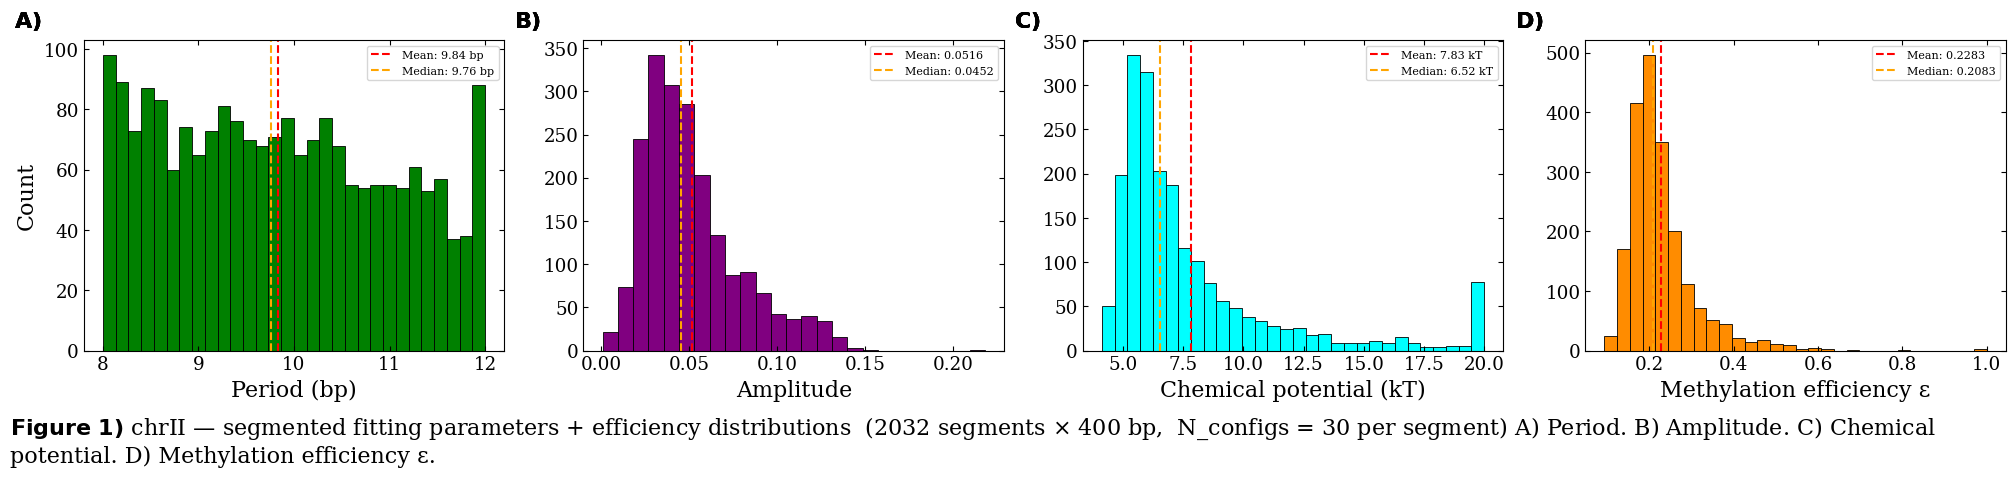

In [5]:
import json

# ── Full-chromosome methylation efficiency estimation ──────────────────────
# Resumable: re-running picks up from the last completed segment.
# Saves to segmented_fitting_params/chrII_efficiency.npz

chrom_name     = "chrII"
segment_length = 400
padding        = 1000
N_configs      = 30       # MC samples per segment; more = smoother mean_base
genome_fasta   = r".genomes/sacCer3/sacCer3.fa"

out_dir   = Path("segmented_fitting_params")
eff_path  = out_dir / f"{chrom_name}_efficiency.npz"
ckpt_path = out_dir / f"{chrom_name}_efficiency_checkpoint.json"

# --- Load fitted params ---
fit_data   = np.load(out_dir / f"{chrom_name}_filtered_params.npz")
periods_c  = fit_data['period']
amps_c     = fit_data['amplitude']
chems_c    = fit_data['chemical_potential']
chrom_len  = int(fit_data['chrom_len'])
n_segs     = len(periods_c)
print(f"{chrom_name}: {n_segs} segments × {segment_length} bp  (chrom_len={chrom_len:,})")

# --- Load genome sequence (re-fetch in case cell 885d9c2c hasn't run) ---
chrom_number_c = chrom_name.lstrip("chr")
chromosome_c   = fetch_chromosome_sequence(genome_fasta, chromosome=chrom_number_c)

# --- Load chromosome-wide experimental methylation ---
meth_full_c = np.load(f"full_methylation_data_10000bp_interval/{chrom_name}/methylation_{chrom_name}.npy")
print(f"Methylation array: {meth_full_c.shape}  mean (>0): {meth_full_c[meth_full_c > 0].mean():.4%}")

# --- Resume or start fresh ---
if eff_path.exists() and ckpt_path.exists():
    d_eff      = np.load(eff_path)
    eff_chrom  = d_eff['efficiency'].copy()
    completed  = set(json.loads(ckpt_path.read_text()))
    print(f"  Resuming: {len(completed)}/{n_segs} segments done")
else:
    eff_chrom = np.full(n_segs, np.nan)
    completed = set()

# --- Fit each segment ---
for k in tqdm(range(n_segs), desc=f"Efficiency {chrom_name}"):
    if k in completed:
        continue

    seg_start = k * segment_length
    seg_end   = min(seg_start + segment_length, chrom_len)
    seq_start = max(0, seg_start - padding)
    seq_end   = min(chrom_len, seg_end + padding)
    pad_lo    = seg_start - seq_start      # index of seg_start inside padded sequence
    inner_len = seg_end - seg_start

    seg_fiber = ChromatinFiber(sequence=chromosome_c[seq_start:seq_end], start=seq_start)
    seg_fiber.calc_energy_landscape(
        octamer=True,
        period=float(periods_c[k]),
        amplitude=float(amps_c[k]),
        chemical_potential=float(chems_c[k]),
    )

    # Monte Carlo mean accessibility at ε=1
    base_stack = []
    for _ in range(N_configs):
        dyads = seg_fiber.sample_fiber_configuration()
        r     = seg_fiber.calc_methylation(dyads, motifs=['A'], strand='both', efficiency=1.0)
        base_stack.append(r.methylated[pad_lo : pad_lo + inner_len])
    mean_base = np.nanmean(base_stack, axis=0)   # (inner_len,)

    # Experimental methylation for this segment
    exp_k = meth_full_c[seg_start:seg_end]
    mask  = (exp_k > 0) & ~np.isnan(mean_base) & (mean_base > 0)

    if mask.sum() == 0:
        eff_chrom[k] = np.nan
    else:
        av = mean_base[mask]
        ev = exp_k[mask]
        # Exact least-squares: ε = (a·e) / (a·a), clipped to [0, 1]
        eff_chrom[k] = float(np.clip(np.dot(av, ev) / np.dot(av, av), 0.0, 1.0))

    completed.add(k)
    np.savez(eff_path, efficiency=eff_chrom,
             segment_length=np.array(segment_length),
             chrom_len=np.array(chrom_len))
    ckpt_path.write_text(json.dumps(list(completed)))

print(f"\nSaved → {eff_path}")
valid_eff   = eff_chrom[~np.isnan(eff_chrom)]
mean_eff    = float(valid_eff.mean())
median_eff  = float(np.median(valid_eff))
print(f"Valid segments : {len(valid_eff)}/{n_segs}")
print(f"ε — mean: {mean_eff:.4f}   median: {median_eff:.4f}   std: {valid_eff.std():.4f}")

# --- 4-panel histogram: period / amplitude / chem_pot / efficiency ---
plotter = Plotter(fig_size=(20, 4))
plotter.new(ncols=4, nrows=1)
ax1, ax2, ax3, ax4 = plotter.axes

ax1.hist(periods_c,  bins=30, color='green',      edgecolor='black', linewidth=0.6)
ax1.axvline(np.mean(periods_c),   color='red',    ls='--', label=f'Mean: {np.mean(periods_c):.2f} bp')
ax1.axvline(np.median(periods_c), color='orange', ls='--', label=f'Median: {np.median(periods_c):.2f} bp')
ax1.set_xlabel("Period (bp)")
ax1.set_ylabel("Count")
ax1.legend(fontsize=8)

ax2.hist(amps_c,     bins=25, color='purple',     edgecolor='black', linewidth=0.6)
ax2.axvline(np.mean(amps_c),   color='red',    ls='--', label=f'Mean: {np.mean(amps_c):.4f}')
ax2.axvline(np.median(amps_c), color='orange', ls='--', label=f'Median: {np.median(amps_c):.4f}')
ax2.set_xlabel("Amplitude")
ax2.legend(fontsize=8)

ax3.hist(chems_c,    bins=30, color='cyan',       edgecolor='black', linewidth=0.6)
ax3.axvline(np.mean(chems_c),   color='red',    ls='--', label=f'Mean: {np.mean(chems_c):.2f} kT')
ax3.axvline(np.median(chems_c), color='orange', ls='--', label=f'Median: {np.median(chems_c):.2f} kT')
ax3.set_xlabel("Chemical potential (kT)")
ax3.legend(fontsize=8)

ax4.hist(valid_eff,  bins=30, color='darkorange', edgecolor='black', linewidth=0.6)
ax4.axvline(mean_eff,   color='red',    ls='--', label=f'Mean: {mean_eff:.4f}')
ax4.axvline(median_eff, color='orange', ls='--', label=f'Median: {median_eff:.4f}')
ax4.set_xlabel("Methylation efficiency ε")
ax4.legend(fontsize=8)

ax1.set_title("Period")
ax2.set_title("Amplitude")
ax3.set_title("Chemical potential")
ax4.set_title("Methylation efficiency ε")

plotter.caption(
    f"{chrom_name} — segmented fitting parameters + efficiency distributions  "
    f"({n_segs} segments × {segment_length} bp,  N_configs = {N_configs} per segment)"
)